Task 1: Data Understanding and Visualization:
Download the Provided Data and Complete the following task.
1. Load and visualize images from a dataset stored in directories, where each subdirectory represents a class. You are expected to write a code:

• Get the list of class directories from the train folder.

• Select one image randomly from each class.

• Display the images in a grid format with two rows using matplotlib.
• Expected Output:

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

In [4]:
train_dir = "/content/drive/MyDrive/AI and Machine Learning/Week5/FruitinAmazon/train"

# Get class folders
classes = os.listdir(train_dir)

images = []

# Select one random image from each class
for cls in classes:
    class_path = os.path.join(train_dir, cls)
    if os.path.isdir(class_path):
        img_name = random.choice(os.listdir(class_path))
        img_path = os.path.join(class_path, img_name)
        images.append((cls, img_path))

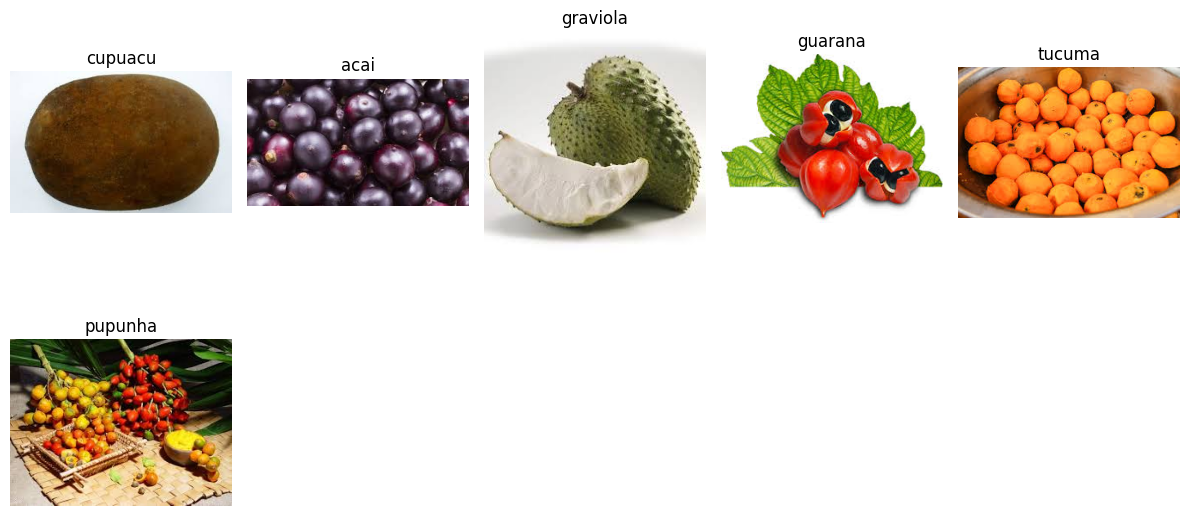

In [5]:
# Plot images (2 rows)
plt.figure(figsize=(12, 6))
for i, (cls, img_path) in enumerate(images[:10]):  # limit to 10 images
    img = Image.open(img_path)
    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

2. Check for Corrupted Image:
 Write a script that verifies whether the image in the train
directory are valid. If any corrupted images are found, the script must remove the image from
the directory and print the message which image have been removed, if none found print ”No
Corrupted Images Found.”
• Hint:– Iterate through each class subdirectory and check if each image is valid.– Use the Image.open() function to attempt to load each image.– If the image is corrupted i.e. raises an IOError or SyntaxError, remove the image from
the directory and print f"Removed corrupted image: {image_path}".– Maintain a list of all corrupted image paths for reporting.
• Expected Output: No corrupted images found

In [6]:
from PIL import Image
import os

corrupted = []

for cls in os.listdir(train_dir):
    class_path = os.path.join(train_dir, cls)

    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            try:
                img = Image.open(img_path)
                img.verify()
            except (IOError, SyntaxError):
                corrupted.append(img_path)
                os.remove(img_path)
                print(f"Removed corrupted image: {img_path}")

if len(corrupted) == 0:
    print("No corrupted images found.")

No corrupted images found.


Task2: Loading and Preprocessing Image Data in keras:

In this section,we will load and preprocess image data from a directory using the
image dataset from directory function in Keras.

In [7]:
import tensorflow as tf

img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

train_dir = "/content/drive/MyDrive/AI and Machine Learning/Week5/FruitinAmazon/train"

# Normalization
rescale = tf.keras.layers.Rescaling(1./255)

# Training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)


Found 90 files belonging to 6 classes.
Using 72 files for training.


In [8]:
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 18 files for validation.


Task 3- Implement a CNN with
Follow the following Structure and Hyper- parameters

Convolutional Architecture:

• Convolutional Layer 1:
– Filter Size (F): (3,3)
– Number of Filters (k): 32
– Padding (P): same
– Stride (s): 1
• Activation Layer: ReLU activation
• Pooling Layer 1: Max pooling
– Filter Size (F): (2,2)
– Stride (s): 2

• Convolutional Layer 2:
– Filter Size (F): (3,3)
– Number of Filters (k): 32
– Padding (P): same–
 Stride (s): 1
• Activation Layer: ReLU activation
• Pooling Layer 2: Max pooling
– Filter Size (F): (2,2)
– Stride (s): 2

Fully Connected Network Architecture:
• Flatten Layer: Flatten the input coming from the convolutional layers
• Input Layer:
• Hidden Layer- 2:– Number of Neurons: 64– Number of Neurons: 128
• Output Layer:– Number of Neurons: num classes (number of output classes)


In [9]:
from tensorflow.keras import layers, models

num_classes = len(os.listdir(train_dir))

model = models.Sequential([
    # Conv Layer 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu',
                  input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    # Conv Layer 2
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Fully Connected
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Task 4: Compile the Model
Model Compilation
• Choose an appropriate optimizer (e.g., Adam), loss function (e.g., sparse categorical crossentropy),
and evaluation metric (e.g., accuracy).

In [10]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Task 4: Train the Model
Model Training
• Use the model.fit() function to train the model. Set the batch size to 16 and the number of epochs
to 250.
• Use val ds for validation.
• Use callbacks such as ModelCheckpoint and EarlyStopping for saving the best model and avoid
ing overfitting

In [11]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint("best_model.h5", save_best_only=True)
early_stop = EarlyStopping(patience=10, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    batch_size=16,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.1545 - loss: 1.9634

3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 552ms/step - accuracy: 0.1667 - loss: 2.0221 - val_accuracy: 0.2222 - val_loss: 1.8047
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.2639 - loss: 1.6515

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 536ms/step - accuracy: 0.2917 - loss: 1.6337 - val_accuracy: 0.7778 - val_loss: 1.2754
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.5110 - loss: 1.5286

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 453ms/step - accuracy: 0.4861 - loss: 1.5151 - val_accuracy: 0.7778 - val_loss: 1.1300
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 415ms/step - accuracy: 0.4583 - loss: 1.3089 - val_accuracy: 0.7222 - val_loss: 1.3196
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - accuracy: 0.6036 - loss: 1.1051

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 446ms/step - accuracy: 0.6389 - loss: 1.0949 - val_accuracy: 0.7778 - val_loss: 0.7435
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 402ms/step - accuracy: 0.7778 - loss: 0.8373 - val_accuracy: 0.7778 - val_loss: 0.8197
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 757ms/step - accuracy: 0.9028 - loss: 0.5924 - val_accuracy: 0.7778 - val_loss: 0.9331
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.9196 - loss: 0.4321

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 561ms/step - accuracy: 0.9306 - loss: 0.3946 - val_accuracy: 0.8889 - val_loss: 0.4266
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 410ms/step - accuracy: 0.9444 - loss: 0.2387 - val_accuracy: 0.8333 - val_loss: 0.4555
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 411ms/step - accuracy: 1.0000 - loss: 0.0931 - val_accuracy: 0.7778 - val_loss: 0.9491
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 407ms/step - accuracy: 1.0000 - loss: 0.0921 - val_accuracy: 0.8889 - val_loss: 0.6623
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 420ms/step - accuracy: 0.9444 - loss: 0.0922 - val_accuracy: 0.8333 - val_loss: 0.7161
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 716ms/step - accuracy: 0.9861 - loss: 0.0501 - val_accuracy: 0.8333 - val_loss: 0.5154
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 695ms/step - accuracy: 0.9722 - loss: 0.0535 - val_accuracy: 0.8889 - val_loss: 0.4598
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 412ms/step - accuracy: 1.0000 - loss: 0.0146 - val_accuracy: 0.8333 - val_los

Task 5: Evaluate the Model
Model Evaluation
• After training, evaluate the model using model.evaluate() on the test set to check the test
accuracy and loss.

In [12]:
test_loss, test_acc = model.evaluate(val_ds)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.8889 - loss: 0.4266
Test Accuracy: 0.8888888955116272
Test Loss: 0.4266378581523895


Task 6: Save and Load the Model
Model Saving and Loading
• Save the trained model to an .h5 file using model.save().
• Load the saved model and re-evaluate its performance on the test set.

In [13]:
# Save model
model.save("cnn_model.h5")

# Load model
from tensorflow.keras.models import load_model
loaded_model = load_model("cnn_model.h5")

# Re-evaluate
loss, acc = loaded_model.evaluate(val_ds)
print("Loaded Model Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.8889 - loss: 0.4266
Loaded Model Accuracy: 0.8888888955116272


Task 7: Predictions and Classification Report
Making Predictions
• Use model.predict() to make predictions on test images.
• Convert the model’s predicted probabilities to digit labels using np.argmax().
• Also use from sklearn.metrics import classification
Report of your Model Performance.


In [14]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images)
    preds = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         0
           4       1.00      0.67      0.80         3
           5       0.93      0.93      0.93        15

    accuracy                           0.89        18
   macro avg       0.64      0.53      0.58        18
weighted avg       0.94      0.89      0.91        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
